内置数据


In [2]:
import pandas as pd
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objs as go
import numpy as np

In [3]:
data = pd.read_csv('assist.csv', encoding="ISO-8859-1", low_memory=False)
data.head(), data.shape, data.columns

(   user_id  problem_id                                 skill problem_type  \
 0    61394      365981                              Rounding      algebra   
 1    61394      426415  Multiplication and Division Integers      algebra   
 2    61394       86686                            Proportion      algebra   
 3    76592      401234                             Exponents      algebra   
 4    78401       87699   Equation Solving Two or Fewer Steps      algebra   
 
    ms_first_response  attempt_count  correct  
 0              21175              1      1.0  
 1               8645              1      0.0  
 2              25728              1      1.0  
 3              12522              1      1.0  
 4              61439              1      1.0  ,
 (2630080, 7),
 Index(['user_id', 'problem_id', 'skill', 'problem_type', 'ms_first_response',
        'attempt_count', 'correct'],
       dtype='object'))

In [4]:
key = 'problem_id'
diff = data[[key, 'correct']].groupby([key]).apply(lambda r:r['correct'].sum() / len(r['correct']))
diff

problem_id
1         0.000000
2         0.000000
3         0.000000
6         1.000000
13        0.962963
            ...   
766195    0.000000
766201    0.000000
766222    1.000000
766225    0.000000
766231    1.000000
Length: 50988, dtype: float64

In [5]:
key_qd = 'difficulty'
data[key_qd] = data['problem_id'].map(diff)
data.head(), data.shape, data.columns

(   user_id  problem_id                                 skill problem_type  \
 0    61394      365981                              Rounding      algebra   
 1    61394      426415  Multiplication and Division Integers      algebra   
 2    61394       86686                            Proportion      algebra   
 3    76592      401234                             Exponents      algebra   
 4    78401       87699   Equation Solving Two or Fewer Steps      algebra   
 
    ms_first_response  attempt_count  correct  difficulty  
 0              21175              1      1.0    0.714286  
 1               8645              1      0.0    0.398058  
 2              25728              1      1.0    0.443662  
 3              12522              1      1.0    0.894737  
 4              61439              1      1.0    0.664384  ,
 (2630080, 8),
 Index(['user_id', 'problem_id', 'skill', 'problem_type', 'ms_first_response',
        'attempt_count', 'correct', 'difficulty'],
       dtype='object'))

In [6]:
key_s = 'skill_id'
skill_id_dict = dict(zip(data['skill'].unique(), range(len(data['skill'].unique()))))
data[key_s] = data['skill'].map(skill_id_dict)
data.head(), data.shape, data.columns

(   user_id  problem_id                                 skill problem_type  \
 0    61394      365981                              Rounding      algebra   
 1    61394      426415  Multiplication and Division Integers      algebra   
 2    61394       86686                            Proportion      algebra   
 3    76592      401234                             Exponents      algebra   
 4    78401       87699   Equation Solving Two or Fewer Steps      algebra   
 
    ms_first_response  attempt_count  correct  difficulty  skill_id  
 0              21175              1      1.0    0.714286         0  
 1               8645              1      0.0    0.398058         1  
 2              25728              1      1.0    0.443662         2  
 3              12522              1      1.0    0.894737         3  
 4              61439              1      1.0    0.664384         4  ,
 (2630080, 9),
 Index(['user_id', 'problem_id', 'skill', 'problem_type', 'ms_first_response',
        'attemp

In [7]:
# sns.stripplot(x='skill_id', y='difficulty', data=data)
# plt.show()

### 将skill_id为0到9的数据抽取

In [8]:
df = data[data.skill_id < 10]
df.head(), df.shape, df.columns

(   user_id  problem_id                                 skill problem_type  \
 0    61394      365981                              Rounding      algebra   
 1    61394      426415  Multiplication and Division Integers      algebra   
 2    61394       86686                            Proportion      algebra   
 3    76592      401234                             Exponents      algebra   
 4    78401       87699   Equation Solving Two or Fewer Steps      algebra   
 
    ms_first_response  attempt_count  correct  difficulty  skill_id  
 0              21175              1      1.0    0.714286         0  
 1               8645              1      0.0    0.398058         1  
 2              25728              1      1.0    0.443662         2  
 3              12522              1      1.0    0.894737         3  
 4              61439              1      1.0    0.664384         4  ,
 (633094, 9),
 Index(['user_id', 'problem_id', 'skill', 'problem_type', 'ms_first_response',
        'attempt

### 在上一步的基础上，随机采样200个问题

In [9]:

import os
import random
import numpy as np
seed = 1024
random.seed(seed)     # python的随机性
np.random.seed(seed)

In [10]:
df1 = df.sample(n=200, axis=0)
df1.head(), df1.shape, df1.columns

(         user_id  problem_id                                skill  \
 769677    222104      409633   Addition and Subtraction Fractions   
 119523    175503      685426  Equation Solving Two or Fewer Steps   
 478677    175105      452554                           Proportion   
 1673343   223214      423036     Write Linear Equation from Graph   
 2251143   132241      185905                            Unit Rate   
 
         problem_type  ms_first_response  attempt_count  correct  difficulty  \
 769677     fill_in_1              92332              1      1.0    0.437500   
 119523      choose_1               4090              1      1.0    0.958763   
 478677       algebra              38001              1      1.0    0.959184   
 1673343      algebra             184509              0      0.0    0.605536   
 2251143      algebra              23233              1      0.0    0.462687   
 
          skill_id  
 769677          6  
 119523          4  
 478677          2  
 1673343    

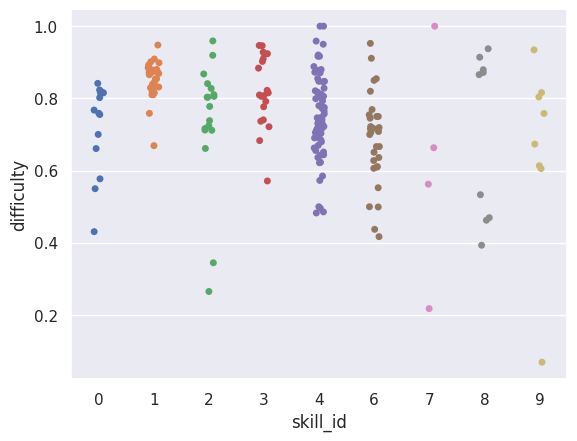

In [11]:
sns.stripplot(x='skill_id', y='difficulty', data=df1)
plt.savefig('/home/czy/KT/1/pictures/fig6_assist12_difficulty.eps', dpi=300)  # eps文件，用于LaTeX
plt.show()